# Computation, Visualization, and Analysis of Pythagorean Triplets

$Author$: Michael Simons

$Class$: MTH 337 - Mathematical & Scientific Computing

$Date$: 9/17/22

## Introduction

An essential concept in geometry is The *Pythagorean Theorem*.
Given lengths of the perpindicular sides of a right trangle $a$ and $b$, aswell as the length  $c$ of third side which is opposing the right angle, the theorem states that the following equation is always true:

$a^2 + b^2 = c^2$

A combination of numbers $(a,b,c)$ for which the theorem is satisfied is known as a *Pythagorean* ***Triple***. The smaller two numbers $(a,b)$ are signified as a *Pythagorean* ***Tuple***.

Example: $3^2 + 4^2 = 5^2$ is true, showing that $(3,4,5)$ is a Pythagorean Triple, and $(3,4)$ is a Pythagorean Tuple.

This report will aim to compute and analyze the natural structure of Pythagorean Triples.

## Efficiently Identifying Pythagorean Triples

A prerequisite to the analysis is a method of computing triples. An initial idea is to iteratively produce combinations of three numbers and verify the Pythagorean Theorem. However, there is a significant observation to consider:

$a^2+b^2=c^2 \implies c=\sqrt{a^2+b^2}$

This indicates that producing a combination of two integers $a$ and $b$ followed by a verification that their respective $c$ value is an integer would produce a pythagorean triple. This algorithm is more efficient because it will require fewer operations than producing combinations of three numbers.

A final optimization can be realized before implementation. In a pythagorean tuple, at least one of the integers will be even. This can be proven via modular arithmitic. To summarize, there can not be a Pythagorean Triple such that $a,b,c$ are all odd. This is because the square of an odd number is always odd, meaning $a^2$ and $b^2$ are both odd. The sum of two odd numbers is always an even number, and this means that $c^2$ must be even and therefore $c$ cannot be odd, and one of $a$ or $b$ must be even.

With these important concepts in mind, an efficient function to compute the triples will be constructed:

In [1]:
# Computes all positive Pythagorean Triples such that a and b <= the integer argument
def ptriples(n,accumulator=[]):
    for a in range(1,n+1):                         #Produce each combination of potential Pyth. Tuples
        for b in range(2,n+1,2):                   #Inc. by two because at least one number has to be even
            c=(((a**2)+(b**2))**0.5)              
            if(c%1==0):                            #Verify that c is an integer, if so, a triple has been found
                accumulator.insert(0,[a,b,int(c)]) #Inserting to index 0 is faster than using the append method
    return accumulator                             #Give back the accumulated list of triples

To test the function for correctness, it will compute positive pythagorean triples with $a,b \leq 20$

In [2]:
print(ptriples(20))

[[16, 12, 20], [15, 20, 25], [15, 8, 17], [12, 16, 20], [9, 12, 15], [8, 6, 10], [6, 8, 10], [5, 12, 13], [3, 4, 5]]


Observably, the function correctly computes pythagorean triples with a,b less than or equal to the given input. It will now be utilized to store triples where $a,b \leq 750$, for later use.

In [3]:
triples=ptriples(750) # Stored in the form [[a,b,c],[a,b,c]...]

## Visualizing Pythagorean Tuples

With the triples stored, it will be simple to plot their respective tuples using matplotlib, a library which includes a convenient method of plotting data. The x-axis will represent each triple's $a$ value and the y-axis will represent each triple's $b$ value.

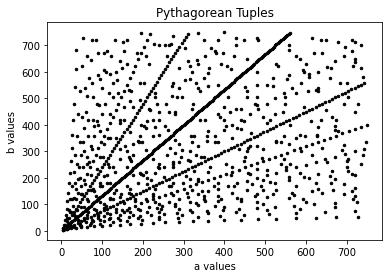

In [4]:
#Plotting Pythagorean Tuples
import matplotlib.pyplot as plt
a_values=[p[0] for p in triples] #Read a and b values from previously stored triples
b_values=[p[1] for p in triples]
plt.plot(a_values,b_values,'.k',ms=5)  #Show the pythagorean tuples data on a black dot plat, x being the a value and y being b
plt.title("Pythagorean Tuples")
plt.xlabel("a values")
plt.ylabel("b values")
plt.show();

As expected, we immediately see linear patterns among the tuples. This is due to the fact that a valid Pythagorean Tuple can be multiplied by a scalar to produce another valid Pythagorean Tuple. Ex: $(3,4,5)$ is valid therefore $(6,8,10)$ is also valid as it is $(3,4,5)$ times a scalar of $2$. 

Since $(6,8)$ is a Pythagorean Tuple and both numbers are reducible by a factor of 2, it will be considered a *non-primitive* tuple.

## Filtering Out Non-Primitives

Plotting every non-primitive tuple is redundant, and a means of distinguishing between primitive tuples and non-primitive tuples is necessary. A tuple is primitive if the greatest common divisor between the two numbers is $1$.

To compute the greatest common divisor of two numbers, we should find the difference between the numbers and recurse with updated values of $a$ and $b$ until the difference is non-existent, then the greatest common divisor is found.

In [5]:
# Computes the greatest common divisor of two given integers
def gcd(a,b):
    if(a<b):a,b=b,a      #Ensure that a is the larger of the two numbers
    k=a%b                #Store the remainder of the two numbers (finding the difference)
    if(k==0):return b    #Greatest Common Divisor found
    else:return gcd(b,k) #Not yet found, recursively call the function with the updated values

The function will be tested for correctness:

In [6]:
print(f"The GCD of 18 and 24 is: {gcd(18,24)}")
print(f"The GCD of 21 and 7 is: {gcd(21,7)}")
print(f"The GCD of 50 and 15 is: {gcd(50,15)}")

The GCD of 18 and 24 is: 6
The GCD of 21 and 7 is: 7
The GCD of 50 and 15 is: 5


The function is correct and will now be used to filter out non-primitive tuples from our plot of Pythagorean Tuples.

In [7]:
primitives=[]                    #Initialize list to accumulate
for T in triples:
    g=gcd(T[0],T[1])             #Compute the gcd of each triple's respective tuple
    if(g==1):
        primitives.insert(0,T)   #Primitive has been found, efficiently add to head of accumulator

## Visualizing Primitive Pythagorean Tuples

Now with the list of primitive pythagorean triples, the data can be easily visualized, as shown previously.

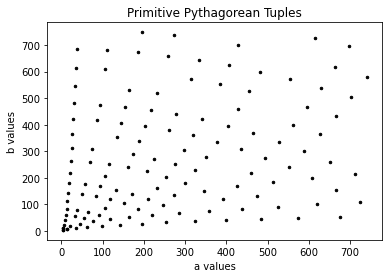

In [8]:
a_values=[p[0] for p in primitives]   #Gather the data for the x-axis and y-axis
b_values=[p[1] for p in primitives]
plt.xlabel("a values")
plt.ylabel("b values")
plt.title("Primitive Pythagorean Tuples")
plt.plot(a_values,b_values,".k",ms=5) #Plot the data with a on the x-axis and b on the y, black dotted.
plt.show();

## Analysis

The results are compelling. The probability of finding a Primitive Tuple is clearly much higher when the values of $a$ and $b$ are smaller. The larger a number becomes, the less likely it is part of a Primitive Tuple. This is a very interesting result.

The curves seem to be approaching vertical asymptotes which is also rather fascinating. For example, The first vertical sequence of tuples seems to be bounded by the equation $x=50$. As $x$ approaches $50$ from the left, the limit seems to be infinity. But from the right, it is clearly $0$.

Each curve seems to behave in a similar way. Another interesting observation is found when examining the behavior of y as x increases. The relation seems to be that as $x$ grows, the $y$ values are likely to decrease. The converse is also true.



## Conclusion
The structure of Pythagorean Triples has some very unusual behavior. It is very difficult to come to conclusion on the meaning of these results. Nonetheless, the procedure leading to the discovery of this odd behavior was a complete success, and further shows the necessity of computation in mathematical and scientific research.